# Real Estate Analysis
## Exploratory Data Analysis
* **Goal:** TBA

In [74]:
# Import libraries for Exploratory Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Safe Dataloading
real_estate_data = ('../data/world_real_estate_data(147k).csv')

try:
    df = pd.read_csv(real_estate_data)
    print(f'File Loaded successfully')
except FileNotFoundError:
    print(f'File Not Found - check {real_estate_data}')
except Exception as e:
    print(f'Error occured - check {e}')

File Loaded successfully


In [76]:
# Inspection of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  object 
 10  apartment_living_area       27712 non-null   object 
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  object 
 13  url           

In [77]:
# Check columns
print(f'Rows: {df.shape[0]} -- Columns: {df.shape[1]}')

Rows: 147536 -- Columns: 14


In [78]:
# Check metrics of Dataset

df.describe()

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


**Note:** Further insepction of 'building_total_floors', 'apartment_floor' and 'appartment_bedrooms', because of negative min values.

In [79]:
# Inspection of first 5 rows

df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


In [80]:
# Check missing values

df.isna().sum()

title                              0
country                          130
location                         131
building_construction_year     82817
building_total_floors          79312
apartment_floor                92944
apartment_rooms                73358
apartment_bedrooms            110554
apartment_bathrooms            91563
apartment_total_area            5740
apartment_living_area         119824
price_in_USD                    2575
image                              0
url                                0
dtype: int64

**Note:** Missing values need to be handled in FE.

In [81]:
# Checking the negativ values for 'building_total_floors'
print(df['building_total_floors'].min())
print(df['building_total_floors'].value_counts().sort_index().head())

-1.0
building_total_floors
-1.0        1
 1.0    10198
 2.0     8209
 3.0     6158
 4.0     4493
Name: count, dtype: int64


In [82]:
# Checking negativ values for 'apartment_floor'
print(df['apartment_floor'].min())
print(df['apartment_floor'].value_counts().sort_index().head())

-2.0
apartment_floor
-2.0       1
-1.0     414
 1.0    9257
 2.0    7994
 3.0    6847
Name: count, dtype: int64


In [83]:
# Checking negativ values for 'apartment_bedrooms'
print(df['apartment_bedrooms'].min())
print(df['apartment_bedrooms'].value_counts().sort_index().head())

-1.0
apartment_bedrooms
-1.0       37
 1.0    11269
 2.0    14433
 3.0     8550
 4.0     1968
Name: count, dtype: int64


### Initial Assessment of Negative Values

Negative values were found in `building_total_floors`, `apartment_floor` and `apartment_bedrooms`.

- `building_total_floors = -1` is likely an invalid value, as a building cannot have a negative number of floors.
- `apartment_floor = -1` could potentially represent a basement or another below-ground floor and should therefore be investigated further before being removed.
- `apartment_bedrooms = -1` occurs only 37 times and may represent missing or unspecified information.

These values will be considered individually during the data-cleaning process rather than being removed automatically.

In [84]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**Note:** No Duplicates in the dataset

In [85]:
# Check prices by country
display(
    df.groupby('country')['price_in_USD']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

,count,mean,median,min,max
country,,,,,
Italy,3002,1.631403e+06,792638.0,23754.0,30602832.0
UAE,2674,1.308989e+06,514822.5,60500.0,29131024.0
United States,414,1.232923e+06,672637.0,108364.0,16843557.0
Portugal,2103,9.649344e+05,675032.0,136620.0,7929687.0
Spain,14937,7.388327e+05,384429.0,32696.0,21738563.0
Croatia,2025,7.147181e+05,413033.0,70647.0,5807513.0
Greece,12341,6.550324e+05,404395.0,30434.0,10981710.0
Australia,1,5.590000e+05,559000.0,559000.0,559000.0
Latvia,2294,5.443125e+05,375574.5,34782.0,6557750.0


### Prices by Country

The analysis shows noticeable differences in both the number of properties and their prices across countries.

- **Italy** has a relatively low number of properties compared to countries such as Spain, Turkey and Hungary, but shows the highest average (`mean`) and median property prices in the dataset.
- **Spain, Turkey and Hungary** have significantly higher numbers of properties, while their average and median prices are considerably lower than those of Italy.
- The large difference between the mean and median in several countries suggests that high-priced properties may be influencing the average price.
- **Hungary** has a minimum price of `$0`, which appears unusual and should be investigated further during the data-cleaning process.
- Countries with very few properties, such as Australia with only one observation, should not be used for meaningful comparisons.

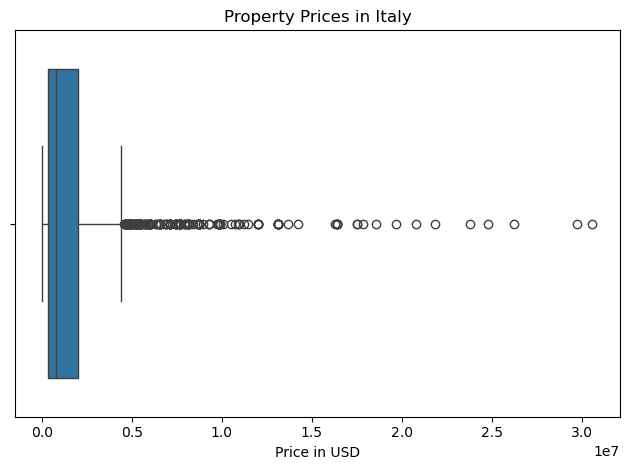

In [86]:
# Check Price for Italy via Boxplot

italy = df[df['country'] == 'Italy']

sns.boxplot(data=italy, x='price_in_USD')

plt.title('Property Prices in Italy')
plt.xlabel('Price in USD')
plt.tight_layout()
plt.show()

### Price Distribution in Italy

The boxplot shows a strongly right-skewed distribution of property prices in Italy. Most properties are concentrated in the lower price range, while numerous high-value outliers extend to more than $30 million.

These extreme values likely pull the mean price of approximately $1.63 million upward. With a median of approximately $793,000, the median appears to be a more representative measure of the typical property price.

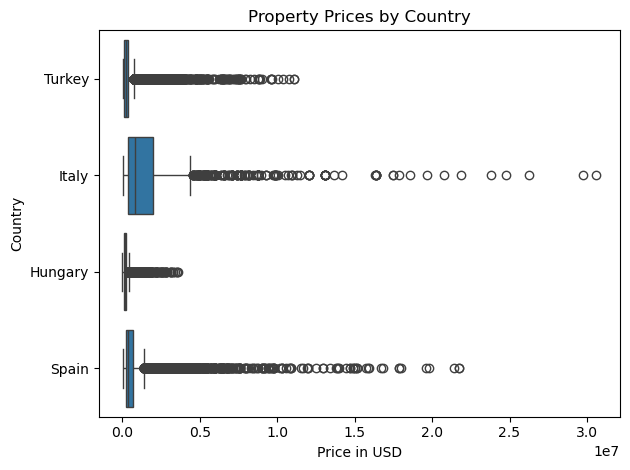

In [87]:
# Check for Price Distribution for Spain, Turkey and Hungary

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

sns.boxplot(
    data=df[df['country'].isin(countries)],
    x='price_in_USD',
    y='country'
)

plt.title('Property Prices by Country')
plt.xlabel('Price in USD')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Price Distribution Comparison

The boxplot shows that property prices are strongly right-skewed in Spain, Turkey and Hungary.

- **Spain** shows the widest price range and several high-value outliers, with some properties exceeding $20 million.
- **Turkey** also has numerous high-value outliers, but the overall price distribution is lower than in Spain.
- **Hungary** has the lowest overall price distribution among the three countries and fewer extreme values.

The large number of high-value outliers in all three countries suggests that extreme property prices may influence the mean and make the median a more representative measure of a typical property price.

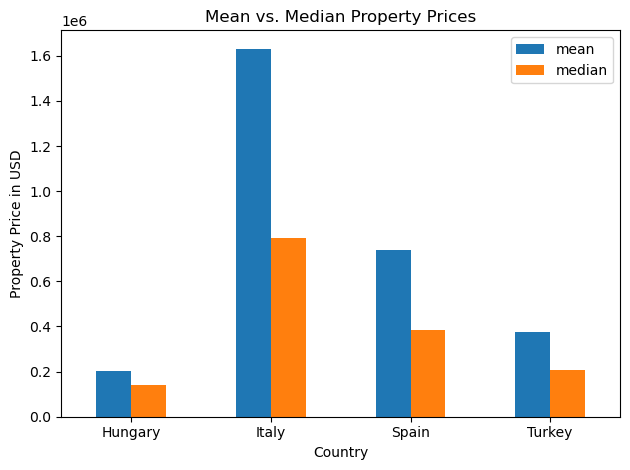

In [88]:
# Price Comparison Mean vs. Median for Spain, Turkey, Hungary and Italy

countries = ['Spain', 'Turkey', 'Hungary', 'Italy']

price_comparison = (
    df[df['country'].isin(countries)]
    .groupby('country')['price_in_USD']
    .agg(['mean', 'median'])
)

price_comparison.plot(kind='bar')

plt.title('Mean vs. Median Property Prices')
plt.xlabel('Country')
plt.ylabel('Property Price in USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Mean vs. Median Price Comparison

The comparison shows that the mean property price is higher than the median in all four countries.

- **Italy** has the highest mean and median prices, with a particularly large difference between the two values.
- **Spain** also shows a noticeable difference between mean and median.
- **Turkey** and **Hungary** have considerably lower price levels, but their means are still higher than their medians.
- The higher mean values are consistent with the right-skewed distributions observed in the boxplots, indicating that high-priced properties are pulling the average price upward.

Overall, the median appears to provide a more representative measure of the typical property price than the mean when extreme values are present.

In [89]:
# Inspect apartment_total_area
print(df['apartment_total_area'].value_counts().head(20))
print('='*30)
print(df['apartment_total_area'].nunique())
print('='*30)
print(df['apartment_total_area'].head(20))

apartment_total_area
100 m²    2468
60 m²     2425
50 m²     2261
55 m²     2112
120 m²    2106
70 m²     2044
90 m²     1944
110 m²    1907
65 m²     1859
75 m²     1837
80 m²     1813
150 m²    1593
40 m²     1510
200 m²    1480
45 m²     1351
38 m²     1344
52 m²     1320
62 m²     1300
53 m²     1290
56 m²     1283
Name: count, dtype: int64
1492
0     120 m²
1     500 m²
2      65 m²
3        NaN
4        NaN
5      28 m²
6     245 m²
7        NaN
8      74 m²
9      50 m²
10     96 m²
11     48 m²
12    312 m²
13    555 m²
14     38 m²
15     54 m²
16     36 m²
17    150 m²
18     25 m²
19     25 m²
Name: apartment_total_area, dtype: object


In [90]:
df[
    df['apartment_total_area'].notna() &
    ~df['apartment_total_area']
    .astype('string')
    .str.match(r'^\d+(\.\d+)?\s*m²$', na=False)
]['apartment_total_area'].unique()

array(['1 000 m²', '130 318 m²', '4 000 m²', '10 069 m²', '1 200 m²',
       '65 000 m²', '12 313 m²', '1 424 m²', '43 492 m²', '1 128 m²',
       '8 460 m²', '13 200 m²', '13 800 m²', '400 000 m²', '2 222 m²',
       '15 273 m²', '1 359 m²', '6 400 m²', '17 500 m²', '515 449 m²',
       '87 000 m²', '10 198 m²', '28 002 m²', '16 197 m²', '45 000 m²',
       '76 000 m²', '142 000 m²', '36 405 773 m²', '183 000 m²',
       '1 056 m²', '19 768 m²', '8 815 m²', '1 052 m²', '425 083 m²',
       '160 000 m²', '1 127 m²', '11 945 m²', '1 350 m²', '2 630 m²',
       '1 150 m²', '1 420 m²', '1 050 m²', '1 406 m²', '1 577 m²',
       '1 121 m²', '2 435 m²', '196 000 m²', '1 030 m²', '1 047 m²',
       '2 500 m²', '1 043 m²', '3 000 m²', '1 300 m²', '1 320 m²',
       '2 700 m²', '1 538 m²', '1 010 m²', '2 200 m²', '1 054 m²',
       '1 220 m²', '1 324 m²', '2 000 m²', '1 356 m²', '1 526 m²',
       '1 270 m²', '9 160 m²', '2 850 m²', '1 001 m²', '1 042 m²',
       '1 037 m²', '1 130 m²', '5 100

In [91]:
# Create new column with only total area numbers without space 
df['apartment_total_area_clean'] = (
    df['apartment_total_area']
    .str.replace(' m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

In [92]:
# Check the new column
df[['apartment_total_area', 'apartment_total_area_clean']].head(20)

,apartment_total_area,apartment_total_area_clean
0,120 m²,120.0
1,500 m²,500.0
2,65 m²,65.0
3,NaN,NaN
4,NaN,NaN
5,28 m²,28.0
6,245 m²,245.0
7,NaN,NaN
8,74 m²,74.0
9,50 m²,50.0


In [93]:
df['apartment_total_area_clean'].describe()

count    1.417960e+05
mean     5.044077e+02
std      9.695024e+04
min      1.000000e+00
25%      5.700000e+01
50%      8.900000e+01
75%      1.500000e+02
max      3.640577e+07
Name: apartment_total_area_clean, dtype: float64

In [94]:
# Inspect apartment_living_area
print(df['apartment_living_area'].value_counts().head(20))
print('='*30)
print(df['apartment_living_area'].nunique())
print('='*30)
print(df['apartment_living_area'].head(20))

apartment_living_area
30 m²    888
17 m²    698
28 m²    639
32 m²    625
29 m²    612
31 m²    554
40 m²    540
33 m²    539
45 m²    513
50 m²    506
34 m²    456
35 m²    453
43 m²    440
44 m²    435
18 m²    432
42 m²    428
36 m²    409
41 m²    387
16 m²    373
38 m²    370
Name: count, dtype: int64
641
0     110 m²
1     480 m²
2      60 m²
3      40 m²
4      36 m²
5        NaN
6     245 m²
7      25 m²
8        NaN
9        NaN
10     86 m²
11       NaN
12       NaN
13       NaN
14     38 m²
15     54 m²
16       NaN
17    135 m²
18       NaN
19       NaN
Name: apartment_living_area, dtype: object


In [95]:
df[
    df['apartment_living_area'].notna() &
    ~df['apartment_living_area']
    .astype('string')
    .str.match(r'^\d+(\.\d+)?\s*m²$', na=False)
]['apartment_living_area'].unique()

array(['13 800 m²', '49 000 m²', '135 000 m²', '47 000 m²', '1 312 m²',
       '35 672 m²', '4 152 m²', '62 692 m²', '42 582 m²', '41 122 m²',
       '41 612 m²', '4 042 m²', '42 482 m²', '54 282 m²', '46 552 m²',
       '60 382 m²', '5 382 m²', '4 972 m²', '89 912 m²', '5 412 m²',
       '74 342 m²', '1 082 m²', '6 242 m²', '6 262 m²', '8 122 m²',
       '6 272 m²', '128 532 m²', '6 912 m²', '67 000 m²', '7 662 000 m²',
       '5 000 m²', '2 400 m²', '1 550 m²', '1 030 m²', '2 500 m²',
       '56 000 m²', '28 773 m²', '14 500 m²', '1 857 m²', '6 336 m²',
       '4 800 m²', '41 462 m²', '41 492 m²', '47 792 m²', '41 392 m²',
       '41 332 m²', '62 542 m²', '81 000 m²', '61 582 m²', '41 922 m²',
       '62 682 m²', '1 450 m²', '1 002 m²', '1 150 m²', '1 033 m²',
       '1 444 m²', '2 140 m²', '2 470 m²', '2 099 m²', '1 621 m²',
       '1 269 m²', '1 225 m²', '1 780 m²', '1 026 m²', '1 800 m²',
       '7 000 m²', '95 000 m²', '1 100 m²', '1 400 m²', '1 230 m²',
       '1 156 m²', '10 56

In [96]:
# Create new column with only total area numbers without space 
df['apartment_living_area_clean'] = (
    df['apartment_living_area']
    .str.replace(' m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

In [97]:
# Check the new column
df[['apartment_total_area', 'apartment_total_area_clean']].head(20)

,apartment_total_area,apartment_total_area_clean
0,120 m²,120.0
1,500 m²,500.0
2,65 m²,65.0
3,NaN,NaN
4,NaN,NaN
5,28 m²,28.0
6,245 m²,245.0
7,NaN,NaN
8,74 m²,74.0
9,50 m²,50.0


In [98]:
df['apartment_living_area_clean'].describe()

count    2.771200e+04
mean     7.435988e+02
std      6.514935e+04
min      1.000000e+00
25%      3.100000e+01
50%      4.600000e+01
75%      8.800000e+01
max      7.662000e+06
Name: apartment_living_area_clean, dtype: float64

In [99]:
# Check if both new columns are numeric
df[['apartment_total_area_clean', 'apartment_living_area_clean']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 2 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   apartment_total_area_clean   141796 non-null  float64
 1   apartment_living_area_clean  27712 non-null   float64
dtypes: float64(2)
memory usage: 2.3 MB


In [100]:
# Quick check of largest apartment_total_area_clean

df.nlargest(
    10, 
    'apartment_total_area_clean'
)[
    ['country', 
    'location',
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD']
]

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
18941,Montenegro,"Bar, Bar Municipality, Montenegro",36405773.0,NaN,78259.0
136130,Italy,"Poggibonsi, Tuscany, Siena, Italy",1250000.0,NaN,16394374.0
110908,Montenegro,"Dobrota, Kotor Municipality, Montenegro",1200000.0,NaN,1304314.0
120333,Poland,"Masovian Voivodeship, Warsaw, Poland",1148000.0,NaN,257272.0
136552,Italy,"Case di Coccia, Marche, Ascoli Piceno, Italy",850000.0,NaN,1912677.0
108540,Spain,"Helechosa de los Montes, Extremadura, Badajoz,...",747579.0,NaN,279341.0
10899,Turkey,"Fatih, Marmara Region, Turkey",515449.0,77.0,546990.0
49669,Hungary,"Nagykanizsa, Transdanubia, Nagykanizsai jaras,...",473884.0,NaN,98408.0
21341,Montenegro,"Bar, Bar Municipality, Montenegro",425083.0,NaN,91302.0
8420,Turkey,"Sariyer, Marmara Region, Cumhuriyet Mahallesi,...",400000.0,NaN,2500000.0


In [101]:
# Quick check of largest apartment_living_area_clean

df.nlargest(
    10, 
    'apartment_living_area_clean'
)[
    ['country', 
    'location',
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD']
]

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
85295,Turkey,"Marmara Region, Turkey",140.0,7662000.0,638000.0
86249,Turkey,"Marmara Region, Turkey",274.0,7662000.0,1200000.0
138269,Portugal,"Centro, Santa Maria Maior, West, Portugal",NaN,220000.0,1038310.0
54394,Hungary,"Heviz, Transdanubia, Keszthelyi jaras, Zala, H...",135000.0,135000.0,318015.0
84612,Austria,"Vienna, Austria",128532.0,128532.0,1084754.0
126024,Greece,"Kriopigi, Macedonia and Thrace, Municipality o...",NaN,95000.0,196950.0
84545,Austria,"Vienna, Austria",89912.0,89912.0,726155.0
94595,Belarus,"Vitsebsk Region, Sakaliscanski sielski Saviet,...",113.0,81000.0,13900.0
84552,Austria,"Vienna, Austria",74342.0,74342.0,553899.0
85110,Turkey,"Marmara Region, Turkey",132.0,67000.0,352000.0


In [102]:
df[df['apartment_total_area_clean'] > 5000][
    ['country',
    'location', 
    'apartment_total_area_clean', 
    'apartment_living_area_clean', 
    'price_in_USD'
    ]
].head(20)

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
1363,Turkey,"Marmara Region, Izmit, Turkey",130318.0,NaN,182000.0
2452,Turkey,"Marmara Region, Fatih Sultan Mehmet Mahallesi,...",10069.0,NaN,149801.0
2760,Turkey,"Mediterranean Region, Sekerhane Mahallesi, Ala...",65000.0,NaN,46609.0
3850,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",12313.0,NaN,782588.0
4309,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",43492.0,NaN,1869311.0
5816,Turkey,"Mediterranean Region, Sekerhane Mahallesi, Ala...",8460.0,NaN,336215.0
5860,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",13200.0,NaN,329339.0
6491,Turkey,"Kargicak, Mediterranean Region, Alanya, Turkey",13800.0,13800.0,NaN
8420,Turkey,"Sariyer, Marmara Region, Cumhuriyet Mahallesi,...",400000.0,NaN,2500000.0
9592,Turkey,"Bahcelievler Mahallesi, Marmara Region, Turkey",15273.0,NaN,581507.0


In [103]:
print((df['apartment_total_area_clean'] > 1000).sum())
print((df['apartment_total_area_clean'] > 5000).sum())

935
254


In [104]:
# Check how much entries of living area are bigger then total area
print((df['apartment_living_area_clean'] > df['apartment_total_area_clean']).sum())

77


In [105]:
# Inspection of the 77 entries
df[df['apartment_living_area_clean'] > df['apartment_total_area_clean']][
    [
        'country', 
        'location', 
        'apartment_total_area_clean', 
        'apartment_living_area_clean', 
        'price_in_USD'
    ]
].head(20)

,country,location,apartment_total_area_clean,apartment_living_area_clean,price_in_USD
1188,Turkey,"Mediterranean Region, Antalya, Turkey",100.0,120.0,226081.0
1356,Turkey,"Koyunlar, Mediterranean Region, Antalya, Turkey",100.0,145.0,149996.0
1556,Turkey,"Avsallar, Mediterranean Region, Alanya, Turkey",109.0,117.0,153257.0
4110,Turkey,"Marmara Region, Turkey",128.0,158.0,744546.0
5809,Turkey,"Marmara Region, Turkey",61.0,82.0,371729.0
8907,Turkey,"Karakocali, Mediterranean Region, Alanya, Turkey",170.0,205.0,586941.0
9593,Turkey,"Marmara Region, Piri Pasa Mahallesi, Turkey",125.0,130.0,373903.0
10173,Turkey,"Marmara Region, Turkey",120.0,145.0,550000.0
10483,Turkey,"Marmara Region, Besevler Mahallesi, Niluefer, ...",430.0,500.0,566290.0
11174,Turkey,"Black Sea Region, Turkey",187.0,256.0,NaN


In [106]:
# Check how much entries of apartment total area are smaller then 500
print(
    df[df['apartment_total_area_clean'] <= 500][
        'apartment_total_area_clean'
    ]
.describe())

count    137940.000000
mean        116.507387
std          90.169010
min           1.000000
25%          56.000000
50%          86.000000
75%         145.000000
max         500.000000
Name: apartment_total_area_clean, dtype: float64


### Assessment of Apartment Area Values

The cleaned area variables were examined for implausible and inconsistent values.

- `apartment_total_area_clean` contains **141,796** non-null values. The median is **86 m²**, while 75% of the observations are below **145 m²**.
- The mean of **504 m²** is substantially higher than the median, indicating a strong influence of extreme values.
- The maximum value of **36,405,773 m²** is clearly implausible for a typical apartment and indicates severe outliers in the dataset.
- **935 observations** have a total area above 1,000 m², and **254 observations** exceed 5,000 m².
- A further consistency check identified **77 observations** where `apartment_living_area_clean` is larger than `apartment_total_area_clean`. These values were considered inconsistent and require careful handling.
- When restricting the total area to values of **500 m² or less**, the mean decreases to **116.5 m²** and the median remains at **86 m²**, resulting in a much more plausible distribution.

For the subsequent analysis of the relationship between apartment area and price, values above **500 m²** will therefore be treated as extreme values and excluded from the analysis variable. The original cleaned area column will be retained to preserve the original information.

In [107]:
# Exclude the outliers from inspection above and only use apartment total area clean with smaller size of 500
df['apartment_total_area_analysis'] = df['apartment_total_area_clean'].where(
    df['apartment_total_area_clean'] <= 500
)

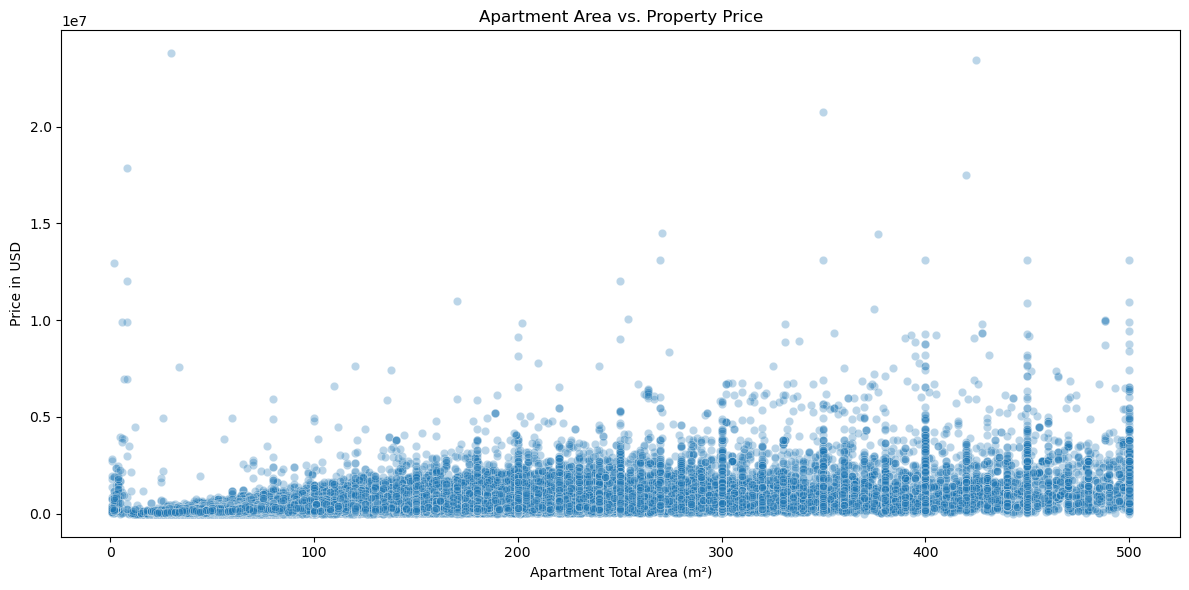

In [110]:
# Check for context between size of the apartment and price
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='apartment_total_area_analysis', 
    y='price_in_USD', 
    alpha=0.3
)

plt.title('Apartment Area vs. Property Price')
plt.xlabel('Apartment Total Area (m²)')
plt.ylabel('Price in USD')
plt.tight_layout()
plt.show()

### Relationship Between Apartment Area and Price

The scatterplot indicates a generally positive relationship between apartment area and property price. Larger apartments tend to have higher prices, but the data points show considerable variation.

Several high-priced properties are visible as outliers, which makes the relationship less clear. Therefore, correlation measures will be used next to quantify the relationship between apartment area and price.

In [111]:
# Correlation check pearson method

correlation_pearson = df[
    ['apartment_total_area_analysis', 'price_in_USD']
].corr(method='pearson')

correlation_pearson

,apartment_total_area_analysis,price_in_USD
apartment_total_area_analysis,1.000000,0.564882
price_in_USD,0.564882,1.000000


In [112]:
# Correlation check spearman method

correlation_spearman = df[
    ['apartment_total_area_analysis', 'price_in_USD']
].corr(method='spearman')

correlation_spearman

,apartment_total_area_analysis,price_in_USD
apartment_total_area_analysis,1.000000,0.701062
price_in_USD,0.701062,1.000000


### Correlation Between Apartment Area and Price

The Pearson correlation coefficient is **0.565**, indicating a moderate positive linear relationship between apartment area and property price.

The Spearman correlation coefficient is **0.701**, indicating a stronger positive monotonic relationship. This suggests that larger apartments generally tend to have higher prices, although the relationship is not strictly linear.

The higher Spearman correlation compared to Pearson indicates that the general ranking between apartment size and price is stronger than their linear relationship. This is consistent with the scatterplot, which shows considerable variation in prices for apartments of similar size.